In [42]:
# セル1: ライブラリのインポート
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ノートブックの位置からプロジェクトルートを解決
project_root = Path.cwd()
if not (project_root / "numbers3_logic.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from numbers3_logic import Numbers3MLPredictor

# プロット設定
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 日本語フォント設定
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# 表示設定
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ ライブラリのインポート完了")

✓ ライブラリのインポート完了


In [43]:
# セル2: データの読み込み
expected_columns = [
    "timestamp",
    "backtest_id",
    "target_round",
    "actual_number",
    "predicted_number",
    "model_type",
    "window_size",
    "num_boost_round",
    "learning_rate",
    "num_leaves",
    "max_depth",
    "straight_hit",
    "box_hit",
    "digit1_correct",
    "digit2_correct",
    "digit3_correct",
    "logloss_digit1",
    "logloss_digit2",
    "logloss_digit3",
    "logloss_avg",
    "confidence_digit1",
    "confidence_digit2",
    "confidence_digit3",
    "confidence_avg",
    "prize_amount",
    "profit",
    "cumulative_profit",
    "roi_percent",
]

# ノートブックの作業ディレクトリに合わせてルートを補正
project_root = Path.cwd()
performance_csv = project_root / "results" / "ml_performance_tracking.csv"
if not performance_csv.exists():
    parent_csv = project_root.parent / "results" / "ml_performance_tracking.csv"
    if parent_csv.exists():
        project_root = project_root.parent
        performance_csv = parent_csv

def _normalize_columns(frame):
    frame.columns = [str(c).strip() for c in frame.columns]
    return frame

def _load_performance_data(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        with open(path, "rb") as f:
            header = f.read(4)
        if header.startswith(b"PK\x03\x04"):
            return pd.read_excel(path)
        raise

# ファイルの存在確認
if not performance_csv.exists():
    print(f"⚠️ 注意: {performance_csv} が見つかりません。")
    print("   まずバックテストを実行してください:")
    print("   python ml_backtest_runner.py --track-performance --rounds 50")
    print("   ここでは空データで続行します。")
    df = pd.DataFrame(columns=expected_columns)
else:
    # データ読み込み
    df = _load_performance_data(performance_csv)
    df = _normalize_columns(df)
    if "timestamp" not in df.columns and not df.empty:
        first_row = [str(v).strip() for v in df.iloc[0].tolist()]
        if "timestamp" in first_row:
            df = df.iloc[1:].copy()
            df.columns = first_row
    df = _normalize_columns(df)
    if not set(expected_columns).issubset(df.columns):
        if df.shape[1] >= len(expected_columns):
            df = df.iloc[:, : len(expected_columns)].copy()
            df.columns = expected_columns
        else:
            print("⚠️ 注意: 期待カラムが見つからないため空データで続行します。")
            df = pd.DataFrame(columns=expected_columns)
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    print("✓ データ読み込み完了")
    print(f"  ファイル: {performance_csv}")
    print(f"  総レコード数: {len(df)}")
    if df.empty:
        print("  ※ レコードがありません。")
    else:
        print(f"  期間: {df['timestamp'].min()} ～ {df['timestamp'].max()}")
        print(f"  バックテストID数: {df['backtest_id'].nunique()}")
        print(f"  対象回号範囲: {df['target_round'].min():.0f} ～ {df['target_round'].max():.0f}")

✓ データ読み込み完了
  ファイル: c:\Users\mieno\Downloads\Python_projects\numbers3\results\ml_performance_tracking.csv
  総レコード数: 40
  期間: 2026-02-09 17:09:01 ～ 2026-02-09 19:37:11
  バックテストID数: 2
  対象回号範囲: 6885 ～ 6914


In [44]:
# セル3: 基本統計
print("=" * 80)
print("📊 基本統計サマリー")
print("=" * 80)

# 全体の統計
print("\n【全体統計】")
print(f"  総テスト回数: {len(df)}")
print(f"  ストレート的中回数: {df['straight_hit'].sum()}")
print(f"  ボックス的中回数: {df['box_hit'].sum()}")
print(f"  ストレート的中率: {df['straight_hit'].mean() * 100:.2f}%")
print(f"  ボックス的中率: {df['box_hit'].mean() * 100:.2f}%")

# 各桁の的中率
print("\n【各桁の的中率】")
print(f"  百の位: {df['digit1_correct'].mean() * 100:.2f}%")
print(f"  十の位: {df['digit2_correct'].mean() * 100:.2f}%")
print(f"  一の位: {df['digit3_correct'].mean() * 100:.2f}%")

# 予測精度（Log-Loss）
print("\n【予測精度（Log-Loss）】")
print(f"  百の位: {df['logloss_digit1'].mean():.4f}")
print(f"  十の位: {df['logloss_digit2'].mean():.4f}")
print(f"  一の位: {df['logloss_digit3'].mean():.4f}")
print(f"  平均: {df['logloss_avg'].mean():.4f}")
print(f"  （Log-Lossは低いほど良い。ランダム予測の場合は約2.303）")

# 信頼度（確率）
print("\n【予測信頼度（確率）】")
print(f"  百の位: {df['confidence_digit1'].mean() * 100:.2f}%")
print(f"  十の位: {df['confidence_digit2'].mean() * 100:.2f}%")
print(f"  一の位: {df['confidence_digit3'].mean() * 100:.2f}%")
print(f"  平均: {df['confidence_avg'].mean() * 100:.2f}%")

# 収益性
print("\n【収益性】")
total_cost = len(df) * 200
total_return = df['prize_amount'].sum()
total_profit = total_return - total_cost
roi = (total_profit / total_cost * 100) if total_cost > 0 else 0
print(f"  総投資額: {total_cost:,}円")
print(f"  総払戻額: {total_return:,}円")
print(f"  損益: {total_profit:+,}円")
print(f"  ROI: {roi:+.2f}%")

# 最終累積損益
if not df.empty:
    final_profit = df.iloc[-1]['cumulative_profit']
    print(f"  最終累積損益: {final_profit:+,}円")

print("\n" + "=" * 80)

📊 基本統計サマリー

【全体統計】
  総テスト回数: 40
  ストレート的中回数: 0
  ボックス的中回数: 0
  ストレート的中率: 0.00%
  ボックス的中率: 0.00%

【各桁の的中率】
  百の位: 17.50%
  十の位: 20.00%
  一の位: 7.50%

【予測精度（Log-Loss）】
  百の位: 4.1226
  十の位: 3.9585
  一の位: 4.5709
  平均: 4.2173
  （Log-Lossは低いほど良い。ランダム予測の場合は約2.303）

【予測信頼度（確率）】
  百の位: 61.83%
  十の位: 59.48%
  一の位: 54.83%
  平均: 58.72%

【収益性】
  総投資額: 8,000円
  総払戻額: 0円
  損益: -8,000円
  ROI: -100.00%
  最終累積損益: -6,000円



In [45]:
# セル4: データのプレビュー
print("\n📋 データのプレビュー（最初の10件）\n")
display_cols = [
    'timestamp', 'target_round', 'actual_number', 'predicted_number',
    'straight_hit', 'logloss_avg', 'confidence_avg', 'profit', 'cumulative_profit'
]
df[display_cols].head(10)


📋 データのプレビュー（最初の10件）



,timestamp,target_round,actual_number,predicted_number,straight_hit,logloss_avg,confidence_avg,profit,cumulative_profit
0,2026-02-09 17:09:01,6914,388,672,0,5.812670,0.775823,-200,-200
1,2026-02-09 17:09:12,6913,470,670,0,1.031989,0.524195,-200,-400
2,2026-02-09 17:09:23,6912,160,121,0,2.561586,0.546177,-200,-600
3,2026-02-09 17:09:35,6911,105,400,0,3.813961,0.494652,-200,-800
4,2026-02-09 17:09:46,6910,37,108,0,5.736283,0.453356,-200,-1000
5,2026-02-09 17:09:58,6909,388,180,0,2.418785,0.567282,-200,-1200
6,2026-02-09 17:10:12,6908,461,774,0,4.537341,0.580043,-200,-1400
7,2026-02-09 17:10:50,6907,447,401,0,3.061814,0.728462,-200,-1600
8,2026-02-09 17:11:00,6906,73,644,0,4.678963,0.636277,-200,-1800
9,2026-02-09 17:11:16,6905,643,544,0,1.992982,0.514421,-200,-2000


✓ グラフを保存しました: results/ml_performance_overview.png


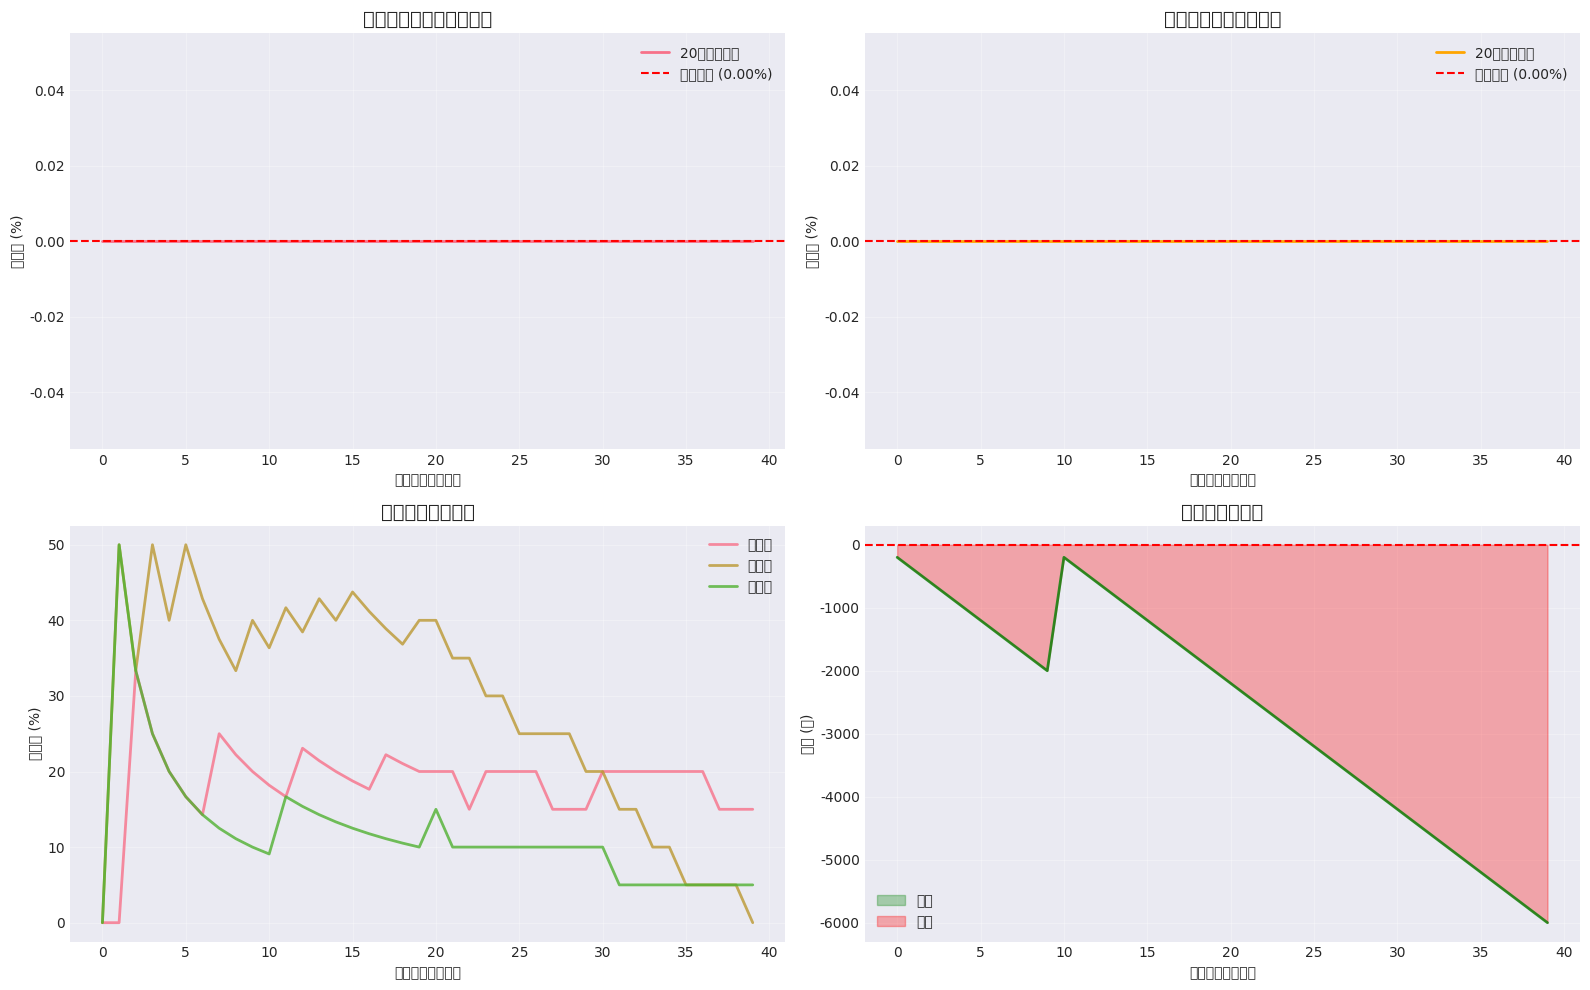

In [46]:
# セル5: 的中率の推移グラフ
if df.empty:
    print("⚠️ データが空のためグラフを生成しません。")
else:
    Path("results").mkdir(exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 移動平均のウィンドウサイズ
    window = 20

    # 1. ストレート的中率の推移
    ax = axes[0, 0]
    df["straight_hit_ma"] = df["straight_hit"].rolling(window, min_periods=1).mean()
    ax.plot(df.index, df["straight_hit_ma"] * 100, label=f"{window}回移動平均", linewidth=2)
    ax.axhline(y=df["straight_hit"].mean() * 100, color="red", linestyle="--", 
           label=f"全体平均 ({df['straight_hit'].mean() * 100:.2f}%)", linewidth=1.5)
    ax.set_title("ストレート的中率の推移", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("的中率 (%)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    # 2. ボックス的中率の推移
    ax = axes[0, 1]
    df["box_hit_ma"] = df["box_hit"].rolling(window, min_periods=1).mean()
    ax.plot(df.index, df["box_hit_ma"] * 100, label=f"{window}回移動平均", 
        linewidth=2, color="orange")
    ax.axhline(y=df["box_hit"].mean() * 100, color="red", linestyle="--", 
           label=f"全体平均 ({df['box_hit'].mean() * 100:.2f}%)", linewidth=1.5)
    ax.set_title("ボックス的中率の推移", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("的中率 (%)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    # 3. 各桁の的中率推移
    ax = axes[1, 0]
    for i in range(1, 4):
        col = f"digit{i}_correct"
        df[f"{col}_ma"] = df[col].rolling(window, min_periods=1).mean()
        digit_name = ["百の位", "十の位", "一の位"][i-1]
        ax.plot(df.index, df[f"{col}_ma"] * 100, label=digit_name, linewidth=2, alpha=0.8)
    ax.set_title("各桁の的中率推移", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("的中率 (%)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    # 4. 累積損益の推移
    ax = axes[1, 1]
    ax.plot(df.index, df["cumulative_profit"], linewidth=2, color="green", alpha=0.8)
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
    ax.fill_between(df.index, df["cumulative_profit"], 0, 
                 where=df["cumulative_profit"] >= 0, alpha=0.3, color="green", label="黒字")
    ax.fill_between(df.index, df["cumulative_profit"], 0, 
                 where=df["cumulative_profit"] < 0, alpha=0.3, color="red", label="赤字")
    ax.set_title("累積損益の推移", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("損益 (円)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/ml_performance_overview.png", dpi=300, bbox_inches="tight")
    print("✓ グラフを保存しました: results/ml_performance_overview.png")
    plt.show()

✓ グラフを保存しました: results/ml_logloss_trends.png


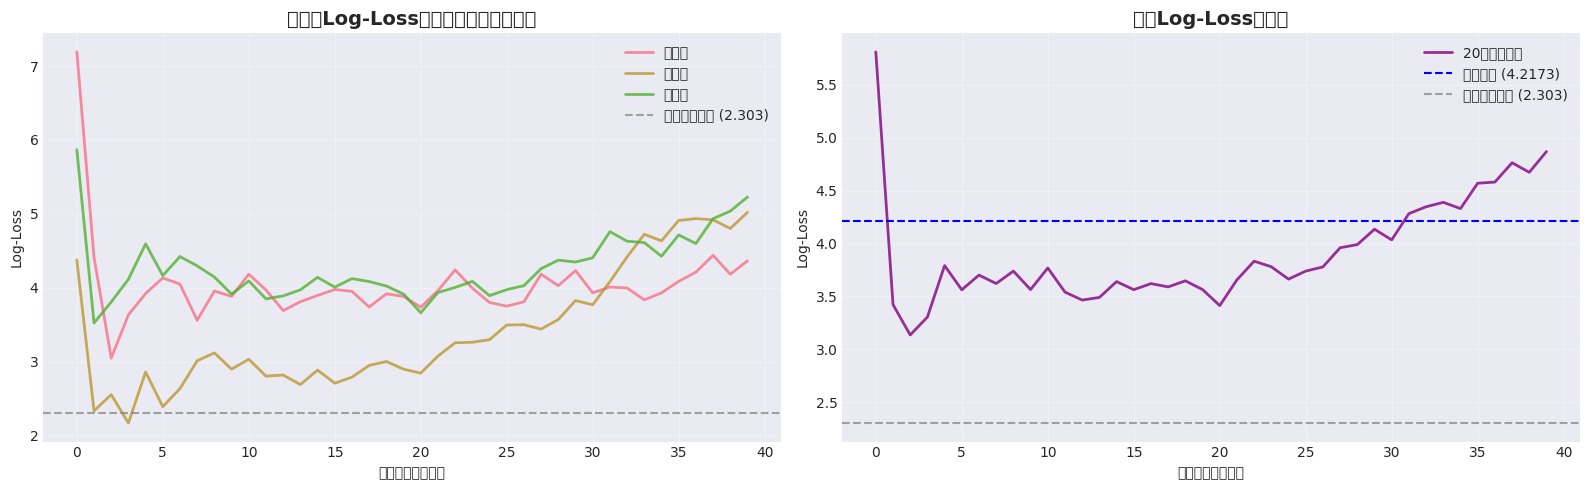

In [47]:
# セル6: Log-Lossの推移
if df.empty:
    print("⚠️ データが空のためグラフを生成しません。")
else:
    Path("results").mkdir(exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. 各桁のLog-Loss推移
    ax = axes[0]
    window_ll = 20
    for i in range(1, 4):
        col = f"logloss_digit{i}"
        df[f"{col}_ma"] = df[col].rolling(window_ll, min_periods=1).mean()
        digit_name = ["百の位", "十の位", "一の位"][i-1]
        ax.plot(df.index, df[f"{col}_ma"], label=digit_name, linewidth=2, alpha=0.8)

    # ランダム予測のLog-Loss（参考値）
    random_logloss = -np.log(0.1)  # 約2.303
    ax.axhline(y=random_logloss, color="gray", linestyle="--", 
           label=f"ランダム予測 ({random_logloss:.3f})", linewidth=1.5, alpha=0.7)

    ax.set_title("各桁のLog-Loss推移（低いほど良い）", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("Log-Loss")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    # 2. 平均Log-Lossの推移
    ax = axes[1]
    df["logloss_avg_ma"] = df["logloss_avg"].rolling(window_ll, min_periods=1).mean()
    ax.plot(df.index, df["logloss_avg_ma"], linewidth=2, color="purple", alpha=0.8, 
        label=f"{window_ll}回移動平均")
    ax.axhline(y=df["logloss_avg"].mean(), color="blue", linestyle="--", 
           label=f"全体平均 ({df['logloss_avg'].mean():.4f})", linewidth=1.5)
    ax.axhline(y=random_logloss, color="gray", linestyle="--", 
           label=f"ランダム予測 ({random_logloss:.3f})", linewidth=1.5, alpha=0.7)
    ax.set_title("平均Log-Lossの推移", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("Log-Loss")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/ml_logloss_trends.png", dpi=300, bbox_inches="tight")
    print("✓ グラフを保存しました: results/ml_logloss_trends.png")
    plt.show()

✓ グラフを保存しました: results/ml_confidence_analysis.png


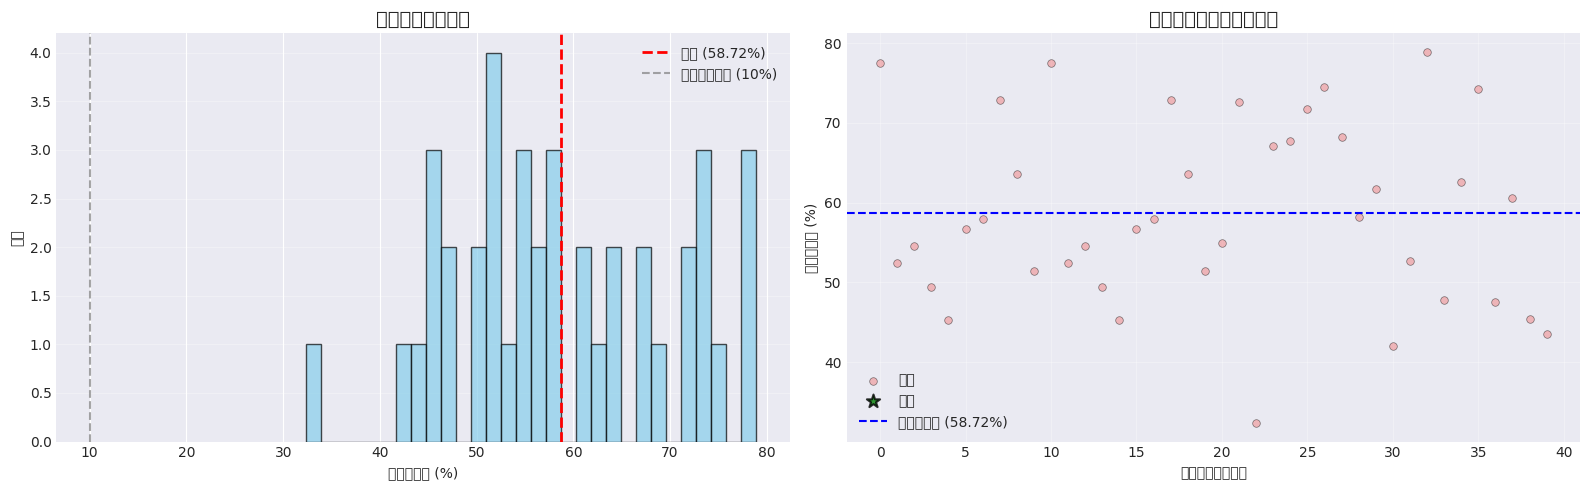

In [48]:
# セル7: 予測信頼度の分析
if df.empty:
    print("⚠️ データが空のためグラフを生成しません。")
else:
    Path("results").mkdir(exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. 信頼度の分布（ヒストグラム）
    ax = axes[0]
    ax.hist(df["confidence_avg"] * 100, bins=30, edgecolor="black", alpha=0.7, color="skyblue")
    ax.axvline(x=df["confidence_avg"].mean() * 100, color="red", linestyle="--", 
           linewidth=2, label=f"平均 ({df['confidence_avg'].mean() * 100:.2f}%)")
    ax.axvline(x=10.0, color="gray", linestyle="--", linewidth=1.5, alpha=0.7,
           label="ランダム予測 (10%)")
    ax.set_title("予測信頼度の分布", fontsize=14, fontweight="bold")
    ax.set_xlabel("平均信頼度 (%)")
    ax.set_ylabel("頻度")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3, axis="y")

    # 2. 信頼度と的中の関係（散布図）
    ax = axes[1]
    # ストレート的中した場合とそうでない場合で色分け
    hit_data = df[df["straight_hit"] == 1]
    miss_data = df[df["straight_hit"] == 0]

    ax.scatter(miss_data.index, miss_data["confidence_avg"] * 100, 
           alpha=0.5, s=30, c="lightcoral", label="外れ", edgecolors="black", linewidths=0.5)
    ax.scatter(hit_data.index, hit_data["confidence_avg"] * 100, 
           alpha=0.8, s=100, c="green", label="的中", edgecolors="black", linewidths=1.5, marker="*")

    ax.axhline(y=df["confidence_avg"].mean() * 100, color="blue", linestyle="--", 
           linewidth=1.5, label=f"平均信頼度 ({df['confidence_avg'].mean() * 100:.2f}%)")
    ax.set_title("予測信頼度と的中の関係", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテスト回数")
    ax.set_ylabel("平均信頼度 (%)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/ml_confidence_analysis.png", dpi=300, bbox_inches="tight")
    print("✓ グラフを保存しました: results/ml_confidence_analysis.png")
    plt.show()

🎯 連続性の分析

【ストレート的中】
  連続的中なし

【ボックス的中】
  連続的中なし

【外れ】
  最大連続外れ: 40回
  平均連続外れ: 40.00回
  連続外れ発生回数: 1回


✓ グラフを保存しました: results/ml_miss_streaks.png


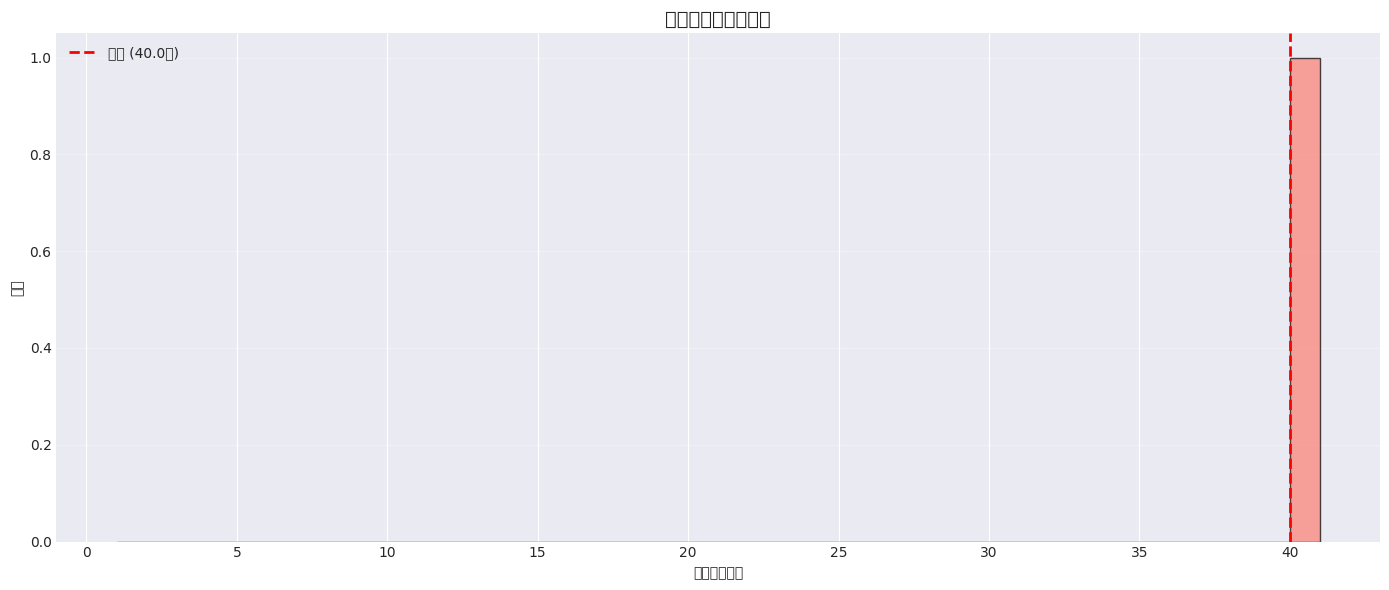

In [49]:
# セル8: 連続的中・外れの分析
if df.empty:
    print("⚠️ データが空のため分析をスキップします。")
else:
    Path("results").mkdir(exist_ok=True)
    def analyze_streaks(series):
        """連続的中・外れを分析"""
        streaks = []
        current_streak = 0
        for val in series:
            if val == 1:
                current_streak += 1
            else:
                if current_streak > 0:
                    streaks.append(current_streak)
                current_streak = 0
        if current_streak > 0:
            streaks.append(current_streak)
        return streaks

    # ストレート的中の連続
    straight_streaks = analyze_streaks(df["straight_hit"].values)

    # ボックス的中の連続
    box_streaks = analyze_streaks(df["box_hit"].values)

    # 外れの連続
    misses = (df["straight_hit"] == 0).astype(int)
    miss_streaks = analyze_streaks(misses.values)

    print("=" * 80)
    print("🎯 連続性の分析")
    print("=" * 80)

    print("\n【ストレート的中】")
    if straight_streaks:
        print(f"  最大連続的中: {max(straight_streaks)}回")
        print(f"  平均連続的中: {np.mean(straight_streaks):.2f}回")
        print(f"  連続的中発生回数: {len(straight_streaks)}回")
    else:
        print("  連続的中なし")

    print("\n【ボックス的中】")
    if box_streaks:
        print(f"  最大連続的中: {max(box_streaks)}回")
        print(f"  平均連続的中: {np.mean(box_streaks):.2f}回")
        print(f"  連続的中発生回数: {len(box_streaks)}回")
    else:
        print("  連続的中なし")

    print("\n【外れ】")
    if miss_streaks:
        print(f"  最大連続外れ: {max(miss_streaks)}回")
        print(f"  平均連続外れ: {np.mean(miss_streaks):.2f}回")
        print(f"  連続外れ発生回数: {len(miss_streaks)}回")

    print("\n" + "=" * 80)

    # 可視化
    fig, ax = plt.subplots(figsize=(14, 6))
    if miss_streaks:
        ax.hist(miss_streaks, bins=range(1, max(miss_streaks) + 2), edgecolor="black", 
            alpha=0.7, color="salmon")
        ax.axvline(x=np.mean(miss_streaks), color="red", linestyle="--", 
               linewidth=2, label=f"平均 ({np.mean(miss_streaks):.1f}回)")
        ax.set_title("連続外れ回数の分布", fontsize=14, fontweight="bold")
        ax.set_xlabel("連続外れ回数")
        ax.set_ylabel("頻度")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.savefig("results/ml_miss_streaks.png", dpi=300, bbox_inches="tight")
        print("\n✓ グラフを保存しました: results/ml_miss_streaks.png")
        plt.show()
    else:
        print("\n（外れデータがないためグラフは表示されません）")

📊 バックテストID別の比較



,ストレート的中,ボックス的中,平均Log-Loss,平均信頼度,最終損益,最終ROI(%),テスト回数
backtest_id,,,,,,,
bt_20260209_170850,0,0,3.5646,0.5821,-2000,-100.0,10
bt_20260209_192840,0,0,4.4349,0.5889,-6000,-100.0,30


✓ グラフを保存しました: results/ml_comparison_by_id.png


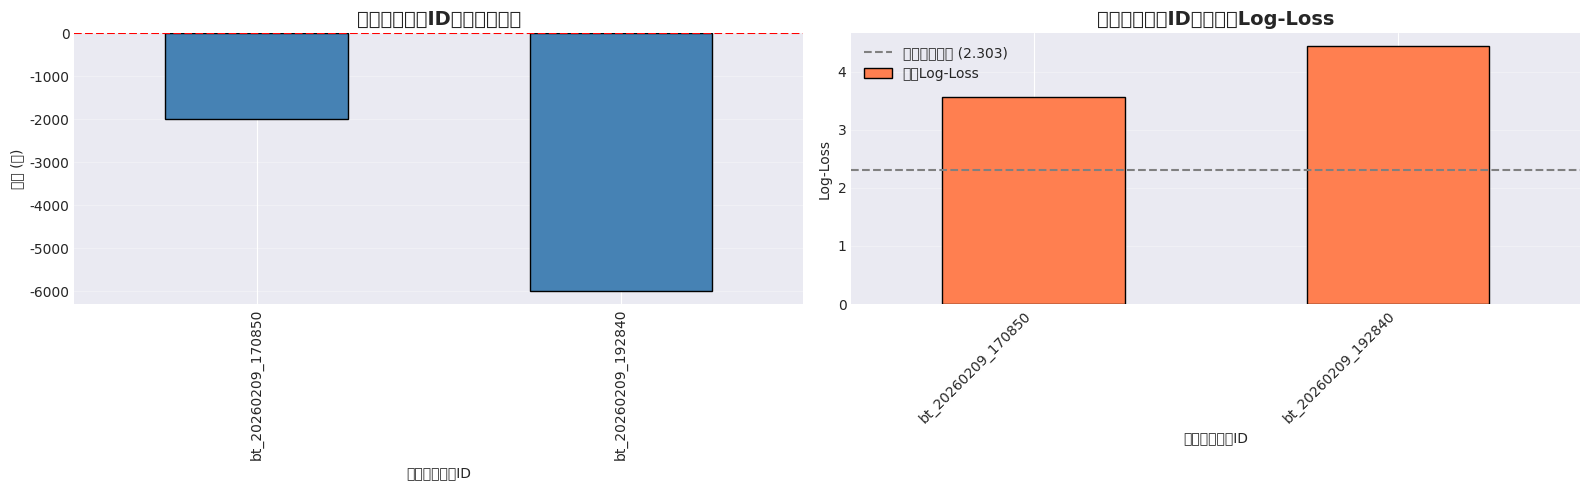

In [50]:
# セル9: バックテストIDごとの比較（複数回実行している場合）
if df.empty:
    print("⚠️ データが空のため比較をスキップします。")
elif df["backtest_id"].nunique() > 1:
    Path("results").mkdir(exist_ok=True)
    print("📊 バックテストID別の比較\n")

    summary_by_id = df.groupby("backtest_id").agg({
        "straight_hit": "sum",
        "box_hit": "sum",
        "logloss_avg": "mean",
        "confidence_avg": "mean",
        "cumulative_profit": "last",
        "roi_percent": "last",
        "target_round": "count",
    }).round(4)

    summary_by_id.columns = [
        "ストレート的中", "ボックス的中", "平均Log-Loss", 
        "平均信頼度", "最終損益", "最終ROI(%)", "テスト回数",
    ]

    display(summary_by_id)

    # 可視化
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 1. 最終損益の比較
    ax = axes[0]
    summary_by_id["最終損益"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title("バックテストID別の最終損益", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテストID")
    ax.set_ylabel("損益 (円)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.xticks(rotation=45, ha="right")

    # 2. 平均Log-Lossの比較
    ax = axes[1]
    summary_by_id["平均Log-Loss"].plot(kind="bar", ax=ax, color="coral", edgecolor="black")
    ax.axhline(y=2.303, color="gray", linestyle="--", linewidth=1.5, 
               label="ランダム予測 (2.303)")
    ax.set_title("バックテストID別の平均Log-Loss", fontsize=14, fontweight="bold")
    ax.set_xlabel("バックテストID")
    ax.set_ylabel("Log-Loss")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3, axis="y")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig("results/ml_comparison_by_id.png", dpi=300, bbox_inches="tight")
    print("✓ グラフを保存しました: results/ml_comparison_by_id.png")
    plt.show()
else:
    print("📊 バックテストIDが1つのみです。複数回実行すると比較ができます。")

In [51]:
# セル10: 特徴量重要度の分析
feature_importance_csv = "results/feature_importance.csv"

if Path(feature_importance_csv).exists():
    print("📊 特徴量重要度の分析\n")
    
    # データ読み込み
    df_importance = pd.read_csv(feature_importance_csv)
    
    # 各桁ごとに集計
    print("【各桁別の重要度トップ5】\n")
    for digit in ["n1", "n2", "n3"]:
        digit_name = {"n1": "百の位", "n2": "十の位", "n3": "一の位"}[digit]
        print(f"{digit_name}:")
        top5 = df_importance[df_importance['digit'] == digit].nlargest(5, 'importance')
        for idx, row in top5.iterrows():
            print(f"  {row['feature']:20s}: {row['importance']:.4f}")
        print()
    
    # 全体の平均重要度
    print("【全桁平均の重要度トップ10】\n")
    avg_importance = df_importance.groupby('feature')['importance'].mean().sort_values(ascending=False)
    for i, (feature, importance) in enumerate(avg_importance.head(10).items(), 1):
        print(f"  {i:2d}. {feature:20s}: {importance:.4f}")
    
else:
    print(f"⚠️  {feature_importance_csv} が見つかりません。")
    print("   バックテストを --track-performance オプション付きで実行してください。")

⚠️  results/feature_importance.csv が見つかりません。
   バックテストを --track-performance オプション付きで実行してください。


In [52]:
# セル11: 特徴量重要度の可視化
if Path(feature_importance_csv).exists():
    df_importance = pd.read_csv(feature_importance_csv)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 各桁別の重要度（上位10件）
    for i, digit in enumerate(["n1", "n2", "n3"]):
        ax = axes[i // 2, i % 2]
        digit_name = {"n1": "百の位", "n2": "十の位", "n3": "一の位"}[digit]
        
        top10 = df_importance[df_importance['digit'] == digit].nlargest(10, 'importance')
        ax.barh(top10['feature'], top10['importance'], color='steelblue', edgecolor='black')
        ax.set_title(f'{digit_name} - 特徴量重要度トップ10', fontsize=12, fontweight='bold')
        ax.set_xlabel('重要度')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis='x')
    
    # 4. 全桁平均の重要度（上位10件）
    ax = axes[1, 1]
    avg_importance = df_importance.groupby('feature')['importance'].mean().sort_values(ascending=False).head(10)
    ax.barh(avg_importance.index, avg_importance.values, color='coral', edgecolor='black')
    ax.set_title('全桁平均 - 特徴量重要度トップ10', fontsize=12, fontweight='bold')
    ax.set_xlabel('重要度')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('results/feature_importance_charts.png', dpi=300, bbox_inches='tight')
    print("✓ グラフを保存しました: results/feature_importance_charts.png")
    plt.show()
    
    # 特徴量のカテゴリ別集計
    print("\n📈 特徴量カテゴリ別の重要度\n")
    
    def categorize_feature(feature_name):
        if 'weekday' in feature_name:
            return '曜日'
        elif 'prev_' in feature_name and not 'ma' in feature_name and not 'std' in feature_name:
            return '前回の値'
        elif 'ma' in feature_name:
            return '移動平均'
        elif 'std' in feature_name:
            return '標準偏差'
        elif feature_name in ['digit_sum', 'odd_count', 'big_count']:
            return '現在の特徴'
        else:
            return 'その他'
    
    df_importance['category'] = df_importance['feature'].apply(categorize_feature)
    category_importance = df_importance.groupby('category')['importance'].sum().sort_values(ascending=False)
    
    for category, importance in category_importance.items():
        print(f"  {category:12s}: {importance:.4f}")
    
    # カテゴリ別の円グラフ
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.Set3(range(len(category_importance)))
    wedges, texts, autotexts = ax.pie(
        category_importance.values,
        labels=category_importance.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 11}
    )
    ax.set_title('特徴量カテゴリ別の重要度割合', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/feature_category_pie.png', dpi=300, bbox_inches='tight')
    print("\n✓ グラフを保存しました: results/feature_category_pie.png")
    plt.show()

In [53]:
# セル12: Markdownレポート生成
from datetime import datetime

report_path = "results/ml_performance_report.md"

# ランダム予測のLog-Loss
random_logloss = -np.log(0.1)

if df.empty:
    print("⚠️ データが空のためレポート生成をスキップします。")
else:
    # 連続性の統計
    straight_streaks = analyze_streaks(df["straight_hit"].values)
    miss_streaks = analyze_streaks((df["straight_hit"] == 0).astype(int).values)

    total_cost = len(df) * 200
    total_return = df["prize_amount"].sum()
    total_profit = total_return - total_cost
    roi_pct = (total_profit / total_cost * 100) if total_cost > 0 else 0.0
    final_cum = df.iloc[-1]["cumulative_profit"] if not df.empty else 0

    # レポート作成
    report = f"""# Numbers3 機械学習モデル精度分析レポート

**生成日時**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**分析期間**: {df['timestamp'].min()} ～ {df['timestamp'].max()}  
**バックテストID数**: {df['backtest_id'].nunique()}

---

## 📊 1. 基本統計

### 全体統計
- **総テスト回数**: {len(df)}回
- **ストレート的中回数**: {df['straight_hit'].sum()}回
- **ストレート的中率**: {df['straight_hit'].mean() * 100:.2f}%
- **ボックス的中回数**: {df['box_hit'].sum()}回
- **ボックス的中率**: {df['box_hit'].mean() * 100:.2f}%

### 各桁の的中率
- **百の位**: {df['digit1_correct'].mean() * 100:.2f}%
- **十の位**: {df['digit2_correct'].mean() * 100:.2f}%
- **一の位**: {df['digit3_correct'].mean() * 100:.2f}%

---

## 🎯 2. 予測精度（Log-Loss）

Log-Lossは予測確率の精度を測る指標で、**低いほど良い**です。  
ランダム予測の場合、Log-Loss = {random_logloss:.4f} となります。

### 各桁のLog-Loss
- **百の位**: {df['logloss_digit1'].mean():.4f}
- **十の位**: {df['logloss_digit2'].mean():.4f}
- **一の位**: {df['logloss_digit3'].mean():.4f}
- **平均**: {df['logloss_avg'].mean():.4f}

### 評価
"""

    # Log-Lossの評価
    avg_logloss = df["logloss_avg"].mean()
    if avg_logloss < random_logloss:
        improvement = ((random_logloss - avg_logloss) / random_logloss * 100)
        report += f"✅ **ランダム予測より {improvement:.1f}% 改善**しています。モデルは有効に学習できています。\n\n"
    elif avg_logloss < random_logloss * 1.05:
        report += "⚠️  ランダム予測とほぼ同等です。特徴量や学習方法の見直しが必要かもしれません。\n\n"
    else:
        report += "❌ ランダム予測より悪化しています。モデルの過学習や特徴量の問題が考えられます。\n\n"

    report += f"""---

## 💰 3. 収益性

### 損益サマリー
- **総投資額**: {total_cost:,}円
- **総払戻額**: {total_return:,}円
- **損益**: {total_profit:+,}円
- **ROI**: {roi_pct:+.2f}%
- **最終累積損益**: {final_cum:+,}円

### 的中内訳
- **セット・ストレート**: {df['straight_hit'].sum()}回 × 37,500円 = {df['straight_hit'].sum() * 37500:,}円
- **セット・ボックス**: {df['box_hit'].sum()}回 × 15,000円 = {df['box_hit'].sum() * 15000:,}円

---

## 📈 4. 連続性の分析

### ストレート的中
"""

    if straight_streaks:
        report += f"""- **最大連続的中**: {max(straight_streaks)}回
- **平均連続的中**: {np.mean(straight_streaks):.2f}回
- **連続的中発生回数**: {len(straight_streaks)}回

"""
    else:
        report += "- 連続的中なし\n\n"

    report += "### 外れ\n"

    if miss_streaks:
        report += f"""- **最大連続外れ**: {max(miss_streaks)}回
- **平均連続外れ**: {np.mean(miss_streaks):.2f}回
- **連続外れ発生回数**: {len(miss_streaks)}回

"""
    else:
        report += "- データ不足\n\n"

    # 特徴量重要度
    if Path(feature_importance_csv).exists():
        df_importance = pd.read_csv(feature_importance_csv)
        avg_importance = df_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)

        report += """---

## 🔍 5. 特徴量重要度

予測に最も寄与している特徴量（トップ10）:

"""
        for i, (feature, importance) in enumerate(avg_importance.head(10).items(), 1):
            report += f"{i}. **{feature}**: {importance:.4f}\n"

        report += "\n"

    report += """---

## 💡 6. 総評と推奨事項

### 現状評価
"""

    # 的中率の評価
    straight_rate = df["straight_hit"].mean() * 100
    if straight_rate > 0.5:
        report += f"- ✅ ストレート的中率 {straight_rate:.2f}% は、ランダム予測（0.1%）を大きく上回っています。\n"
    elif straight_rate > 0.1:
        report += f"- ⚠️  ストレート的中率 {straight_rate:.2f}% は、ランダム予測（0.1%）より高いですが、まだ改善の余地があります。\n"
    else:
        report += f"- ❌ ストレート的中率 {straight_rate:.2f}% は、ランダム予測（0.1%）と同等またはそれ以下です。\n"

    # ROIの評価
    if roi_pct > 0:
        report += f"- ✅ ROI {roi_pct:+.2f}% でプラス収支を達成しています。\n"
    elif roi_pct > -50:
        report += f"- ⚠️  ROI {roi_pct:+.2f}% でマイナス収支ですが、改善の兆しがあります。\n"
    else:
        report += f"- ❌ ROI {roi_pct:+.2f}% で大きな損失が出ています。\n"

    report += """
### 推奨される次のステップ

1. **特徴量エンジニアリングの改善**
   - 重要度の高い特徴量を強化
   - 新しい特徴量の追加（例: 周期性、相関関係など）

2. **ハイパーパラメータチューニング**
   - より広範なパラメータ探索
   - 過学習/未学習のバランス調整

3. **アンサンブル手法の検討**
   - ルールベースモデルとの組み合わせ
   - 複数の機械学習モデルの統合

4. **継続的な監視**
   - 定期的なバックテストで精度を追跡
   - モデルの劣化を早期発見

---

## 📎 添付資料

以下のグラフが `results/` ディレクトリに保存されています:

- `ml_performance_overview.png` - 全体的な精度推移
- `ml_logloss_trends.png` - Log-Loss推移
- `ml_confidence_analysis.png` - 予測信頼度分析
- `ml_miss_streaks.png` - 連続外れ分析
- `feature_importance_charts.png` - 特徴量重要度
- `feature_category_pie.png` - 特徴量カテゴリ別割合

---

**📧 本レポートに関する質問やフィードバックは、プロジェクト管理者までお願いします。**
"""

    # レポート保存
    Path("results").mkdir(exist_ok=True)
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report)

    print(f"✅ レポートを保存しました: {report_path}")
    print("\nレポートの内容:\n")
    print(report[:500] + "...\n")

✅ レポートを保存しました: results/ml_performance_report.md

レポートの内容:

# Numbers3 機械学習モデル精度分析レポート

**生成日時**: 2026-02-10 16:24:40  
**分析期間**: 2026-02-09 17:09:01 ～ 2026-02-09 19:37:11  
**バックテストID数**: 2

---

## 📊 1. 基本統計

### 全体統計
- **総テスト回数**: 40回
- **ストレート的中回数**: 0回
- **ストレート的中率**: 0.00%
- **ボックス的中回数**: 0回
- **ボックス的中率**: 0.00%

### 各桁の的中率
- **百の位**: 17.50%
- **十の位**: 20.00%
- **一の位**: 7.50%

---

## 🎯 2. 予測精度（Log-Loss）

Log-Lossは予測確率の精度を測る指標で、**低いほど良い**です。  
ランダム予測の場合、Log-Loss = 2.3026 となります。

### 各桁のLog-Loss
- **百の位**: 4.1226
- **十の位**: 3.9585
- **一の位**: 4.5709
...



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 770
[LightGBM] [Info] Number of data points in the train set: 1766, number of used features: 16
[LightGBM] [Info] Start training from score -2.358479
[LightGBM] [Info] Start training from score -2.250726
[LightGBM] [Info] Start training from score -2.250726
[LightGBM] [Info] Start training from score -2.234725
[LightGBM] [Info] Start training from score -2.317417
[LightGBM] [Info] Start training from score -2.452592
[LightGBM] [Info] Start training from score -2.213782
[LightGBM] [Info] Start training from score -2.426616
[LightGBM] [Info] Start training from score -2.240030
[LightGBM] [Info] Start training from score -2.311686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000690 seconds.
You c

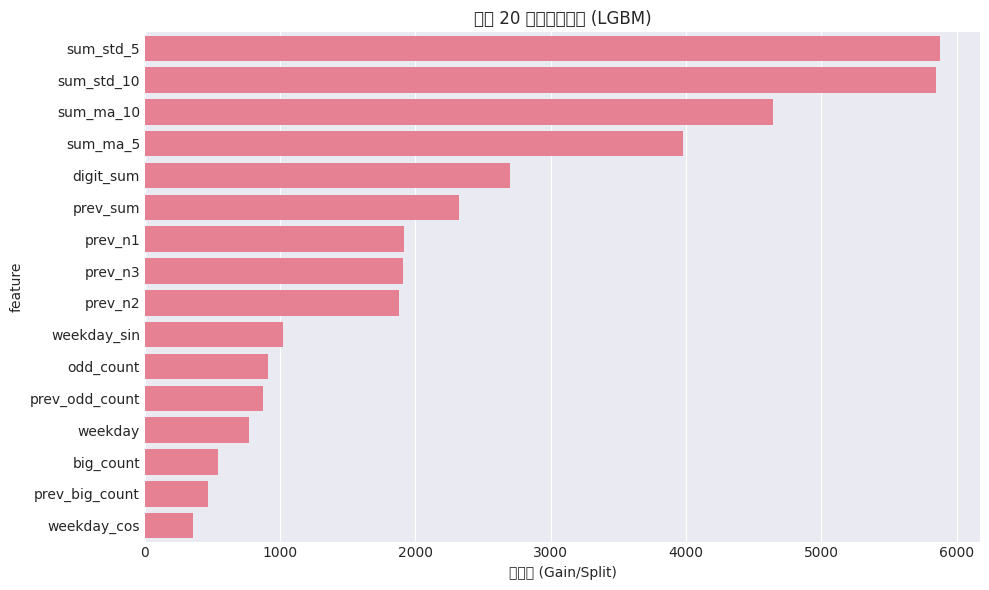

In [55]:
# セル13: 学習と特徴量重要度（元データで学習）
from numbers3_logic import normalize_numbers3_columns

training_csv = project_root / "numbers3_clean.csv"
if not training_csv.exists():
    raise FileNotFoundError(f"学習用データが見つかりません: {training_csv}")

training_df = pd.read_csv(training_csv, encoding="utf-8-sig")
training_df = normalize_numbers3_columns(training_df)

predictor = Numbers3MLPredictor(training_df)
predictor.train()
predictor.plot_importance()